In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Adds the parent directory (project root) to the python path
sys.path.append(os.path.abspath(os.path.join('..')))

In [2]:
from src.modulation import gmsk_mod, gaussianLPF
from src.channel import awgn
from src.demodulation import gmsk_demod
from src.spectra import plot_spectrogram

c:\Users\charl\onedrive\Bureau\Cubesat-Radioastronomie\src\spectra.py:48: SyntaxWarning: invalid escape sequence '\i'
  plotWelchPSD(s4,fs,fc, ax = ax , color = 'k', label = '$BT_b=\infty$')


In [3]:
# Global Parameters
BT = 0.3
Tb = 10
L = 16
k = 4

fc = 146e6

In [4]:
(s_t, s_complex) = gmsk_mod(np.random.randint(0, 2, 10000), fc, L, BT, enable_plot=False)
s_noisy = awgn(s_t, 10)

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
C:\Users\charl\AppData\Local\Temp\ipykernel_34732\1313575371.py:7: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xlabel('Time ($\mu s$)')
C:\Users\charl\AppData\Local\Temp\ipykernel_34732\1313575371.py:14: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_xlabel('Time ($\mu s$)')


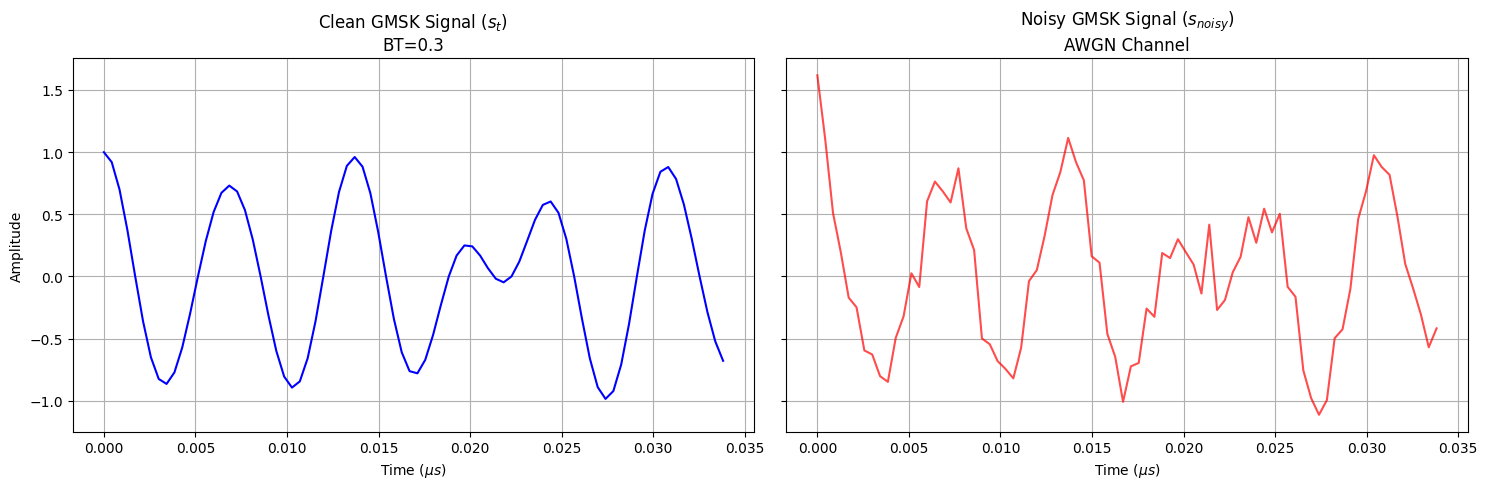

In [5]:
t = np.arange(len(s_t)) / (L * fc)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# Plot Clean Signal
ax1.plot(t[:5*L] * 1e6, s_t[:5*L].real, color='blue')
ax1.set_title(f'Clean GMSK Signal ($s_t$)\nBT={BT}')
ax1.set_xlabel('Time ($\mu s$)')
ax1.set_ylabel('Amplitude')
ax1.grid(True)

# Plot Noisy Signal
ax2.plot(t[:5*L] * 1e6, s_noisy[:5*L].real, color='red', alpha=0.7)
ax2.set_title('Noisy GMSK Signal ($s_{noisy}$)\nAWGN Channel')
ax2.set_xlabel('Time ($\mu s$)')
ax2.grid(True)

plt.tight_layout()
plt.show()

(2.06139313925226e-15+0.9461695300908551j)


c:\Users\charl\onedrive\Bureau\Cubesat-Radioastronomie\src\spectra.py:62: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Sxx = spectrogram(x, fs, nperseg=1024, noverlap=512)


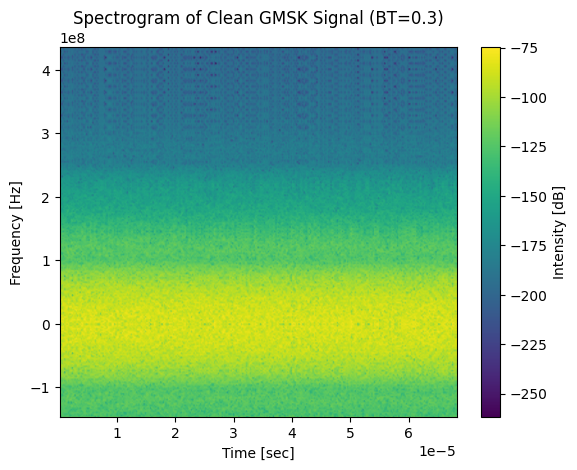

In [6]:
plot_spectrogram(s_t, L*fc, fc, title=f'Spectrogram of Clean GMSK Signal (BT={BT})')

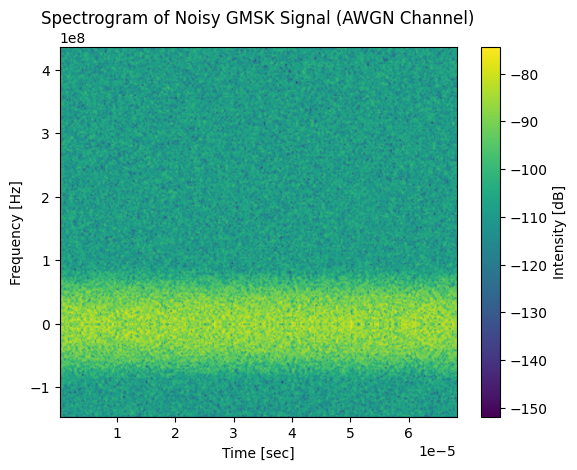

In [7]:
plot_spectrogram(s_noisy, L*fc, fc, title='Spectrogram of Noisy GMSK Signal (AWGN Channel)')